# Music recommendation based on genre, mode, tempo using ML pipeline, evaluation and Hyperparameter tuning


In [1]:
# import base packages
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from narwhals import exclude
from scipy.stats import randint

In [2]:
# import scikit libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier

from sklearn.svm import SVC
from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler
)
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import (
    # validation_curve,
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    # GridSearchCV,
    cross_val_score,
)
from sklearn.feature_selection import (
    mutual_info_classif,
    SelectKBest,
    f_classif,
    RFECV
)

from sklearn.pipeline import Pipeline

In [3]:
import kagglehub

sys.path.insert(0, os.path.abspath('..'))
from data_cleaning import load_and_clean_with_orig

In [4]:
# cleaned dataset
path = kagglehub.dataset_download("vicsuperman/prediction-of-music-genre")
print("Path to dataset files:", path)

processed_df, original_df = load_and_clean_with_orig(os.path.join(path, "music_genre.csv"))
processed_df.head()

Path to dataset files: /Users/pops/.cache/kagglehub/datasets/vicsuperman/prediction-of-music-genre/versions/1


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,valence,music_genre
0,31.0,0.01270,0.622,218293.0,0.890,0.950000,D,0.124,-7.043,Minor,0.0300,115.002,0.531,Electronic
1,28.0,0.00306,0.620,215613.0,0.755,0.011800,G#,0.534,-4.617,Major,0.0345,127.994,0.333,Electronic
2,34.0,0.02540,0.774,166875.0,0.700,0.002530,C#,0.157,-4.498,Major,0.2390,128.014,0.270,Electronic
3,32.0,0.00465,0.638,222369.0,0.587,0.909000,F#,0.157,-6.266,Major,0.0413,145.036,0.323,Electronic
4,46.0,0.02890,0.572,214408.0,0.803,0.000008,B,0.106,-4.294,Major,0.3510,149.995,0.230,Electronic


In [5]:
# One-hot encoding for key, and mode
processed_df = pd.get_dummies(processed_df, columns=['key'], drop_first=True)
processed_df = pd.get_dummies(processed_df, columns=['mode'], drop_first=True)
processed_df = pd.get_dummies(processed_df, columns=['music_genre'], drop_first=True)

print(f"Data shape after one-hot encoding: \n{processed_df.shape}")
print(f"Columns after one-hot encoding: \n{processed_df.columns}")
# print(f"Data sample after one-hot encoding: \n{processed_df.head()}")

Data shape after one-hot encoding: 
(35480, 32)
Columns after one-hot encoding: 
Index(['popularity', 'acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo',
       'valence', 'key_A#', 'key_B', 'key_C', 'key_C#', 'key_D', 'key_D#',
       'key_E', 'key_F', 'key_F#', 'key_G', 'key_G#', 'mode_Minor',
       'music_genre_Anime', 'music_genre_Blues', 'music_genre_Classical',
       'music_genre_Country', 'music_genre_Electronic', 'music_genre_Hip-Hop',
       'music_genre_Jazz', 'music_genre_Rap', 'music_genre_Rock'],
      dtype='str')


In [6]:
# bin tempo
tempo_bins = [30, 95, 120, 140, 200]
tempo_labels = ['Low', 'Comfortable', 'High', 'Very High']
processed_df['tempo_group'] = pd.cut(
    processed_df['tempo'], bins=tempo_bins, labels=tempo_labels, right=False)
print(f"Tempo data after one-hot encoding: \n{processed_df['tempo_group'].head()}")


Tempo data after one-hot encoding: 
0    Comfortable
1           High
2           High
3      Very High
4      Very High
Name: tempo_group, dtype: category
Categories (4, str): ['Low' < 'Comfortable' < 'High' < 'Very High']


In [7]:
# grouped tempo
processed_df['tempo_group'].value_counts()

tempo_group
Very High      9185
Comfortable    9117
Low            8997
High           7997
Name: count, dtype: int64

In [8]:
print(f"Min tempo: {processed_df['tempo'].min()}")
print(f"Max tempo: {processed_df['tempo'].max()}")

Min tempo: 34.347
Max tempo: 220.276


### Visualize pre-processed data

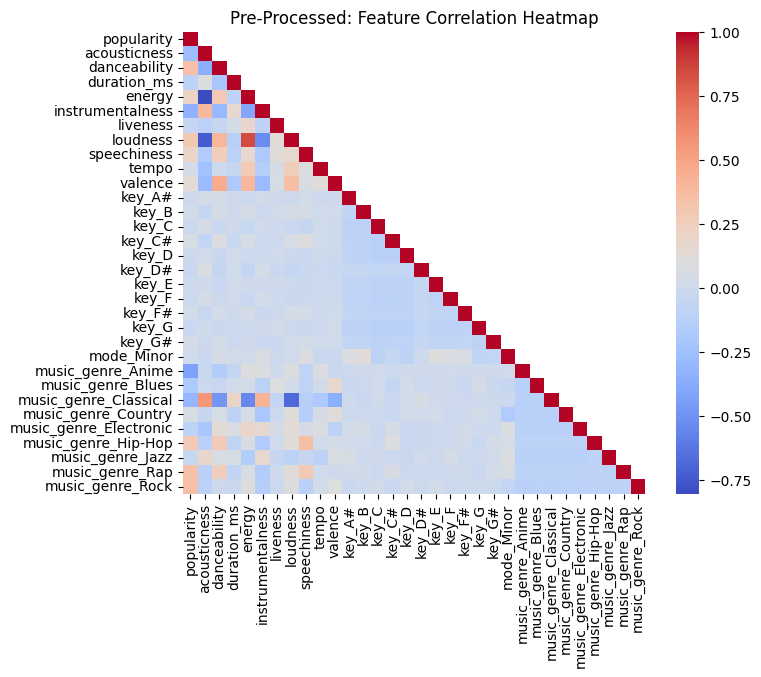

In [9]:
# view new correlation matrix
processed_corr = processed_df.corr(numeric_only=True)

# create the heatmap
mask = np.triu(np.ones_like(processed_corr, dtype=float), k=1)

plt.figure(figsize=(8, 6))
sns.heatmap(processed_corr, mask=mask, cmap='coolwarm', annot=False, square=True)
plt.title('Pre-Processed: Feature Correlation Heatmap')
plt.show()

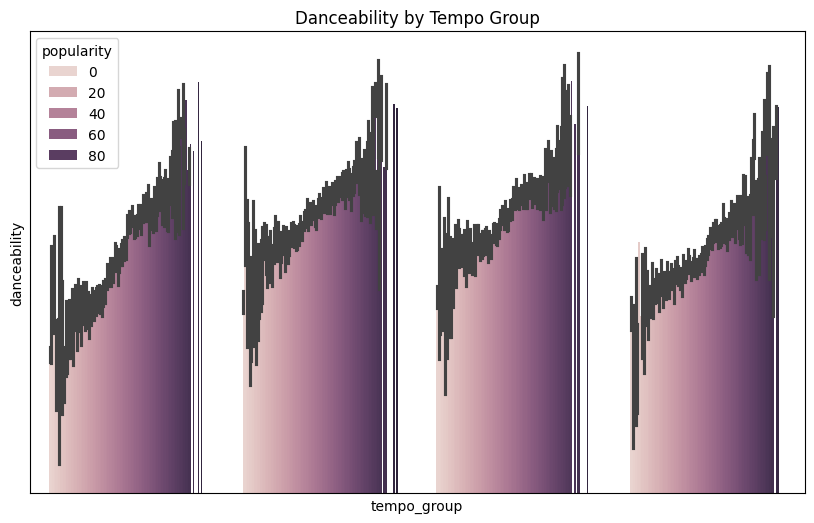

In [10]:
# tempo vs popularity
fig = plt.figure(figsize=(10, 6))
# https://seaborn.pydata.org/generated/seaborn.barplot.html
sns.barplot(data=processed_df, x='tempo_group', y='danceability', hue="popularity")
fig.axes[0].set_xticks(())
fig.axes[0].set_yticks(())
plt.title('Danceability by Tempo Group')
plt.show()

## Combine features

In [11]:
# processed_df = processed_df.drop(columns=['instance_id', 'obtained_date'])
# print(f"Data shape after dropping columns: {processed_df.shape}")

# millisecond duration is converted to minutes, and dropped
processed_df['duration_min'] = processed_df['duration_ms'] / 60000
processed_df = processed_df.drop(columns=['duration_ms'])

# energy and danceability are merged
processed_df['energy_danceability'] = processed_df['energy'] * processed_df['danceability']

# energy and valence are merged
processed_df['energy_valence'] = processed_df['energy'] * processed_df['valence']

# acousticness and instrumentalness are merged
processed_df['acoustic_instrumental'] = processed_df['acousticness'] * processed_df['instrumentalness']

# drop tempo, and keep the tempo_group
processed_df = processed_df.dropna(subset=['tempo']).reset_index(drop=True)

# print the latest data
processed_df.head()

,popularity,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,...,music_genre_Electronic,music_genre_Hip-Hop,music_genre_Jazz,music_genre_Rap,music_genre_Rock,tempo_group,duration_min,energy_danceability,energy_valence,acoustic_instrumental
0,31.0,0.01270,0.622,0.890,0.950000,0.124,-7.043,0.0300,115.002,0.531,...,True,False,False,False,False,Comfortable,3.638217,0.553580,0.472590,1.206500e-02
1,28.0,0.00306,0.620,0.755,0.011800,0.534,-4.617,0.0345,127.994,0.333,...,True,False,False,False,False,High,3.593550,0.468100,0.251415,3.610800e-05
2,34.0,0.02540,0.774,0.700,0.002530,0.157,-4.498,0.2390,128.014,0.270,...,True,False,False,False,False,High,2.781250,0.541800,0.189000,6.426200e-05
3,32.0,0.00465,0.638,0.587,0.909000,0.157,-6.266,0.0413,145.036,0.323,...,True,False,False,False,False,Very High,3.706150,0.374506,0.189601,4.226850e-03
4,46.0,0.02890,0.572,0.803,0.000008,0.106,-4.294,0.3510,149.995,0.230,...,True,False,False,False,False,Very High,3.573467,0.459316,0.184690,2.236860e-07


## Model, and fitting data


In [12]:
_TARGET = "tempo_group"
_NN_count = 5
_RANDOM_STATE = 42

model_map = {
    "Nearest Neighbors": KNeighborsClassifier(_NN_count),  # KNN with 5 neighbours
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(max_depth=_NN_count, random_state=_RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        max_depth=_NN_count, n_estimators=10, max_features=1, random_state=_RANDOM_STATE
    ),  # ensemble method
    "Neural Net": MLPClassifier(alpha=1, max_iter=400, random_state=_RANDOM_STATE),  # neural net
}

In [13]:
# split the dataset in 80% train, 20% test
# following the naming convention for data for model
##  y = target label
##  X = feature labels
transformed_df = processed_df.copy()
le = LabelEncoder()

y = transformed_df[_TARGET]
y = pd.DataFrame(le.fit_transform(y)).values.ravel()
X = transformed_df.drop(_TARGET, axis=1)
X.drop(columns=['tempo'], inplace=True)

se = StandardScaler()

numerical_cols = X.columns[X.dtypes != object]
print(f"numerical_cols: {numerical_cols}")

# split data to test and train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, test_size=0.2, stratify=y, random_state=_RANDOM_STATE
)

X_train_scaled = X_train
X_test_scaled = X_test
X_train_scaled[numerical_cols] = se.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = se.transform(X_test[numerical_cols])
# X_train_selected = X_train_scaled[numerical_cols]
# X_test_selected = X_test_scaled[numerical_cols]

print(f"Test data shape: {X_test.shape}")
print("-----------------------------------------------------")
print(f"Train data shape: {X_train.shape}")

numerical_cols: Index(['popularity', 'acousticness', 'danceability', 'energy',
       'instrumentalness', 'liveness', 'loudness', 'speechiness', 'valence',
       'key_A#', 'key_B', 'key_C', 'key_C#', 'key_D', 'key_D#', 'key_E',
       'key_F', 'key_F#', 'key_G', 'key_G#', 'mode_Minor', 'music_genre_Anime',
       'music_genre_Blues', 'music_genre_Classical', 'music_genre_Country',
       'music_genre_Electronic', 'music_genre_Hip-Hop', 'music_genre_Jazz',
       'music_genre_Rap', 'music_genre_Rock', 'duration_min',
       'energy_danceability', 'energy_valence', 'acoustic_instrumental'],
      dtype='str')
Test data shape: (7096, 34)
-----------------------------------------------------
Train data shape: (28384, 34)


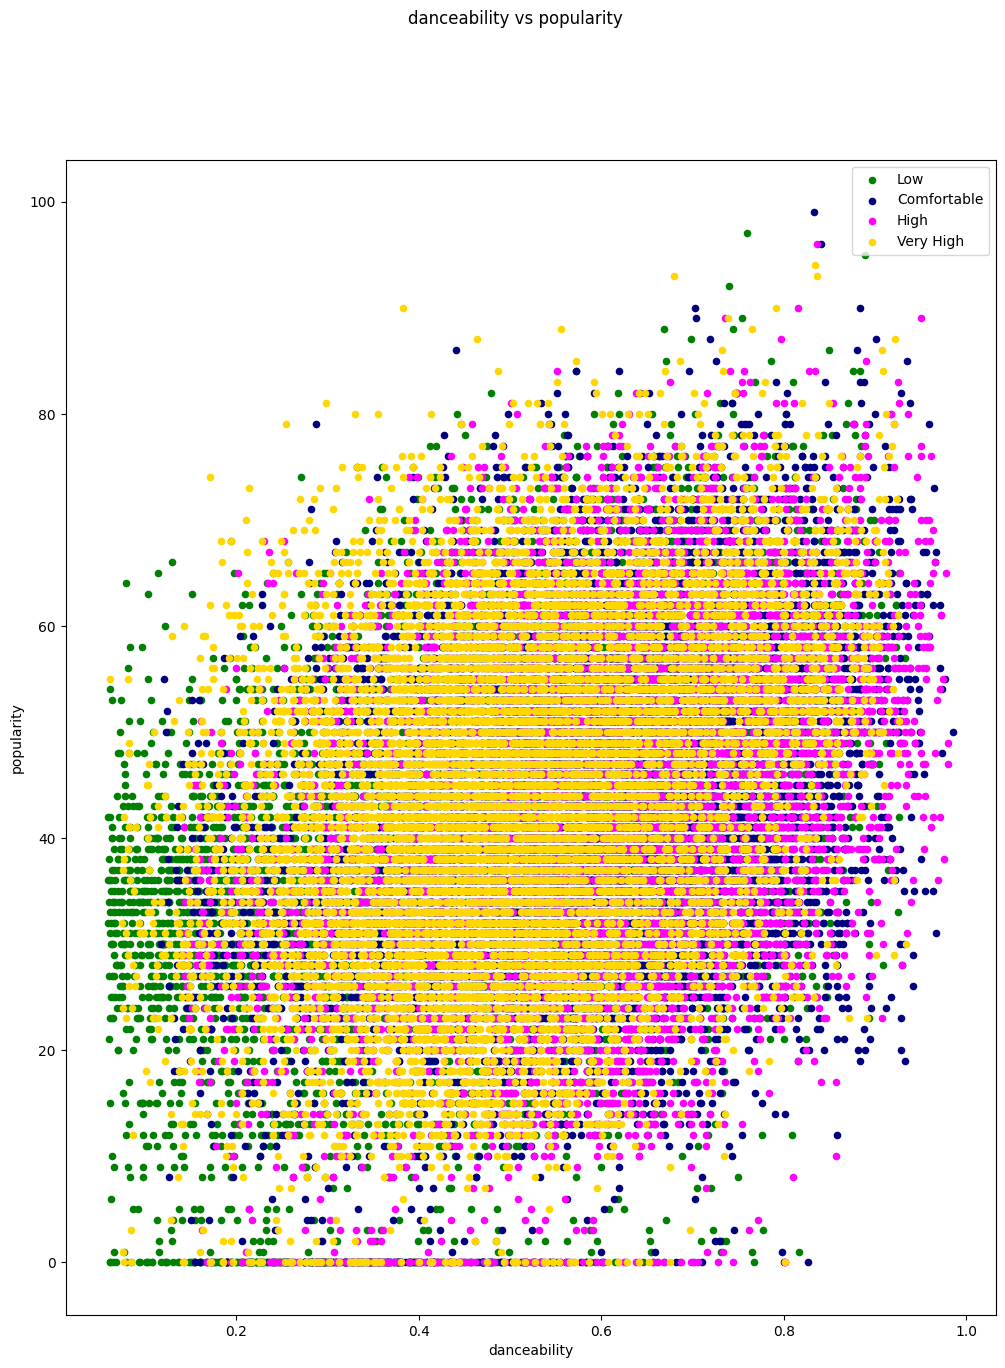

In [14]:
# display data grouped by tempo_group
fig, ax = plt.subplots(figsize=(12, 15))
colors = ['green', 'Navy', 'magenta', 'gold']

i = 0
for tg, data in transformed_df.groupby('tempo_group'):
    data.plot(kind='scatter', x='danceability', y='popularity', label=tg, color=colors[i], ax=ax)
    i = i + 1

# sns.scatterplot(data=processed_df, x='tempo_group', y='valence')
ax.set(xlabel='danceability', ylabel='popularity')
fig.suptitle('danceability vs popularity')
plt.show()

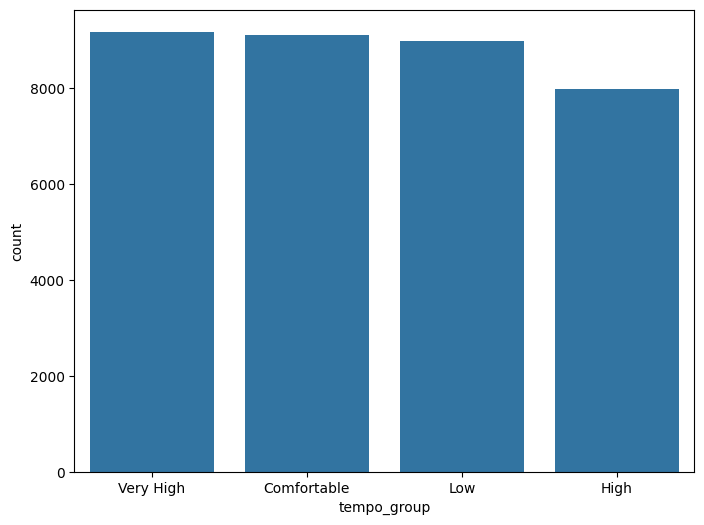

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
# sns.countplot(processed_df, hue="tempo_group", x="danceability",  stat="probability")
sns.countplot(data=processed_df, x='tempo_group', order=processed_df['tempo_group'].value_counts().index)

plt.show()

Baseline: Dummy Classifier
Baseline: Dummy Classifier : 24.77
Accuracy: 0.24774520856820745
3    1902
0    1807
2    1752
1    1591
4      44
Name: count, dtype: int64
Baseline: Dummy Classifier : Confusion Matrix:

[[453 395 460 501  14]
 [406 373 384 423  13]
 [463 404 442 481  10]
 [476 407 457 490   7]
 [  9  12   9   7   0]]
              precision    recall  f1-score   support

           0       0.25      0.25      0.25      1823
           1       0.23      0.23      0.23      1599
           2       0.25      0.25      0.25      1800
           3       0.26      0.27      0.26      1837
           4       0.00      0.00      0.00        37

    accuracy                           0.25      7096
   macro avg       0.20      0.20      0.20      7096
weighted avg       0.25      0.25      0.25      7096

--------------------------------------------------------


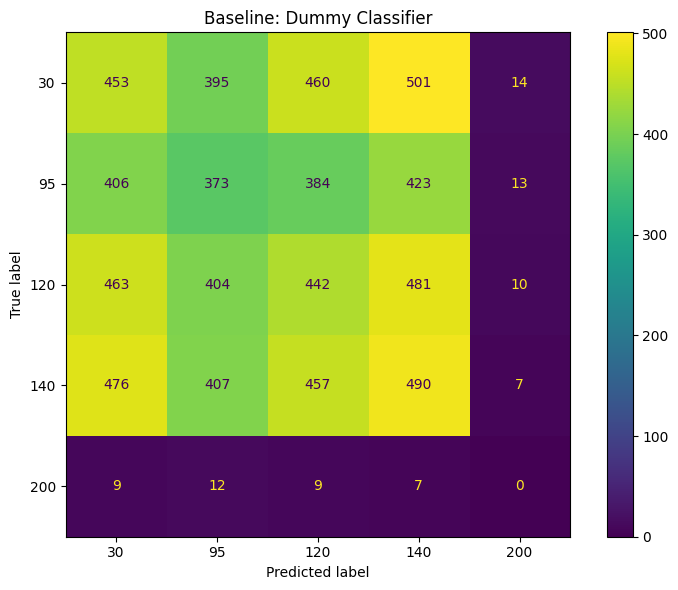

In [16]:
# A dummy classifier, just to set a baseline
dummy_clf = DummyClassifier(strategy="stratified", random_state=_RANDOM_STATE)
dummy_clf.fit(X_train, y_train)
predicted_y = dummy_clf.predict(X_test)

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 6))

print(f"Baseline: Dummy Classifier")
print(f"Baseline: Dummy Classifier : {round(dummy_clf.score(X_test, y_test) * 100, 2)}")
print(f"Accuracy: {accuracy_score(y_test, predicted_y)}")
print(pd.Series(predicted_y).value_counts())
cm = confusion_matrix(y_test, predicted_y)
print("Baseline: Dummy Classifier : Confusion Matrix:\n")
print(cm)
print(classification_report(y_test, predicted_y))
print("--------------------------------------------------------")

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=tempo_bins).plot(ax=axes)
axes.set_title(f"Baseline: Dummy Classifier")

plt.tight_layout()
plt.show()

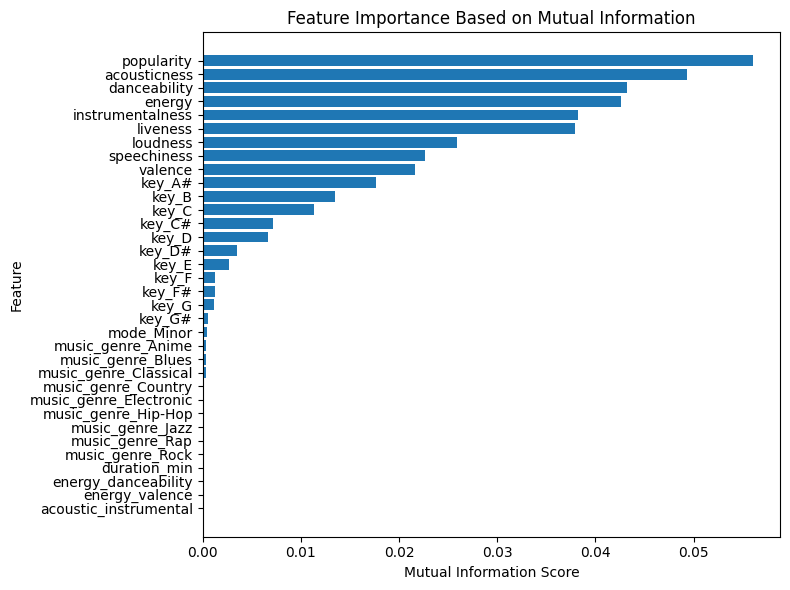

In [17]:
discrete_features = X.columns.str.startswith(('key_', 'mode_', 'music_'))
mutual_info_all = mutual_info_classif(
    X, y,
    discrete_features=discrete_features,
    random_state=_RANDOM_STATE
)
mutual_info_all = pd.Series(mutual_info_all)
mutual_info_all.index = X.columns
mutual_info_all.sort_values(ascending=False, inplace=True)

mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mutual_info_all
})

mi_df = mi_df.sort_values(by='MI Score', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(mi_df['Feature'], mi_df['MI Score'])

plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.title("Feature Importance Based on Mutual Information")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Feature selection with K-folds


In [18]:
## RFE to select feature
# Ref: https://scikit-learn.org/stable/auto_examples/feature_selection/plot_rfe_with_cross_validation.html#sphx-glr-auto-examples-feature-selection-plot-rfe-with-cross-validation-py

min_features_to_select = 1 # Minimum number of features to consider
clf = LogisticRegression(max_iter=500)
cv = StratifiedKFold(10)

rfecv = RFECV(
    estimator=clf,
    step=1,
    cv=cv,
    scoring="accuracy",
    min_features_to_select=min_features_to_select,
    n_jobs=2,
)
rfecv.fit(X_train_scaled, y_train)

print(f"Optimal number of features: {rfecv.n_features_}")

Optimal number of features: 26


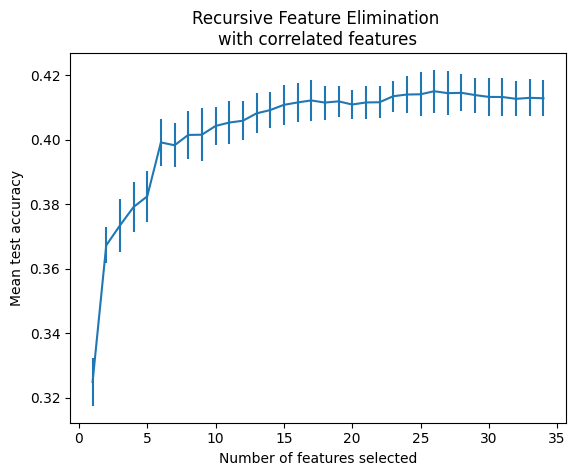

In [19]:
# plot the number of features vs cross-validation

ft_data = {
    key: value
    for key, value in rfecv.cv_results_.items()
    if key in ["n_features", "mean_test_score", "std_test_score"]
}
cv_results = pd.DataFrame(ft_data)
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Mean test accuracy")
plt.errorbar(
    x=cv_results["n_features"],
    y=cv_results["mean_test_score"],
    yerr=cv_results["std_test_score"],
)
plt.title("Recursive Feature Elimination \nwith correlated features")
plt.show()

In [20]:
# optimal features at every step
feat_names = [nm for nm, v in X.items()]

# print(feat_names)

final_set_of_features = set([])

for i in range(cv.n_splits):
    mask = rfecv.cv_results_[f"split{i}_support"][
        rfecv.n_features_ - 1
        ]  # mask of features selected by the RFE
    features_selected = np.ma.compressed(np.ma.masked_array(feat_names, mask=1 - mask))
    # print(f"Features selected in fold {i}: {features_selected}")

print()


In [21]:
# select most important features
# Ref: https://www.geeksforgeeks.org/machine-learning/how-to-identify-the-most-informative-features-for-scikit-learn-classifiers/
selected_features = rfecv.support_
final_set_of_features = [feat_names[i] for i in range(len(feat_names)) if selected_features[i]]
print(f"Selected features : {final_set_of_features}")


Selected features : ['popularity', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'valence', 'key_A#', 'key_B', 'key_C', 'key_E', 'music_genre_Anime', 'music_genre_Blues', 'music_genre_Classical', 'music_genre_Country', 'music_genre_Electronic', 'music_genre_Hip-Hop', 'music_genre_Jazz', 'music_genre_Rap', 'music_genre_Rock', 'duration_min', 'energy_danceability', 'energy_valence', 'acoustic_instrumental']


In [22]:
# data for only selected features
X_train_selected = X_train_scaled[final_set_of_features]
X_test_selected =X_test_scaled[final_set_of_features]

Without Feature Selection: Trained model: Nearest Neighbors
Without Feature Selection: Nearest Neighbors : 35.06
Accuracy: 0.3506200676437429
Confusion Matrix:

[[811 410 333 269   0]
 [581 444 292 282   0]
 [552 325 654 268   1]
 [472 408 377 579   1]
 [  8   4  13  12   0]]
              precision    recall  f1-score   support

           0       0.33      0.44      0.38      1823
           1       0.28      0.28      0.28      1599
           2       0.39      0.36      0.38      1800
           3       0.41      0.32      0.36      1837
           4       0.00      0.00      0.00        37

    accuracy                           0.35      7096
   macro avg       0.28      0.28      0.28      7096
weighted avg       0.35      0.35      0.35      7096

--------------------------------------------------------
Without Feature Selection: Trained model: Logistic Regression
Without Feature Selection: Logistic Regression : 41.7
Accuracy: 0.4169954904171364
Confusion Matrix:

[[ 839  248  

/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

Without Feature Selection: Trained model: Random Forest
Without Feature Selection: Random Forest : 37.22
Accuracy: 0.3721815107102593
Confusion Matrix:

[[ 681   14  374  754    0]
 [ 495   27  280  797    0]
 [ 443    6  714  637    0]
 [ 377   12  229 1219    0]
 [   6    0    9   22    0]]
              precision    recall  f1-score   support

           0       0.34      0.37      0.36      1823
           1       0.46      0.02      0.03      1599
           2       0.44      0.40      0.42      1800
           3       0.36      0.66      0.46      1837
           4       0.00      0.00      0.00        37

    accuracy                           0.37      7096
   macro avg       0.32      0.29      0.25      7096
weighted avg       0.40      0.37      0.33      7096

--------------------------------------------------------


/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

Without Feature Selection: Trained model: Neural Net
Without Feature Selection: Neural Net : 43.74
Accuracy: 0.4374295377677565
Confusion Matrix:

[[ 793  247  407  376    0]
 [ 523  324  349  403    0]
 [ 380  102  881  437    0]
 [ 240  142  349 1106    0]
 [   0    0   12   25    0]]
              precision    recall  f1-score   support

           0       0.41      0.43      0.42      1823
           1       0.40      0.20      0.27      1599
           2       0.44      0.49      0.46      1800
           3       0.47      0.60      0.53      1837
           4       0.00      0.00      0.00        37

    accuracy                           0.44      7096
   macro avg       0.34      0.35      0.34      7096
weighted avg       0.43      0.44      0.42      7096

--------------------------------------------------------


/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

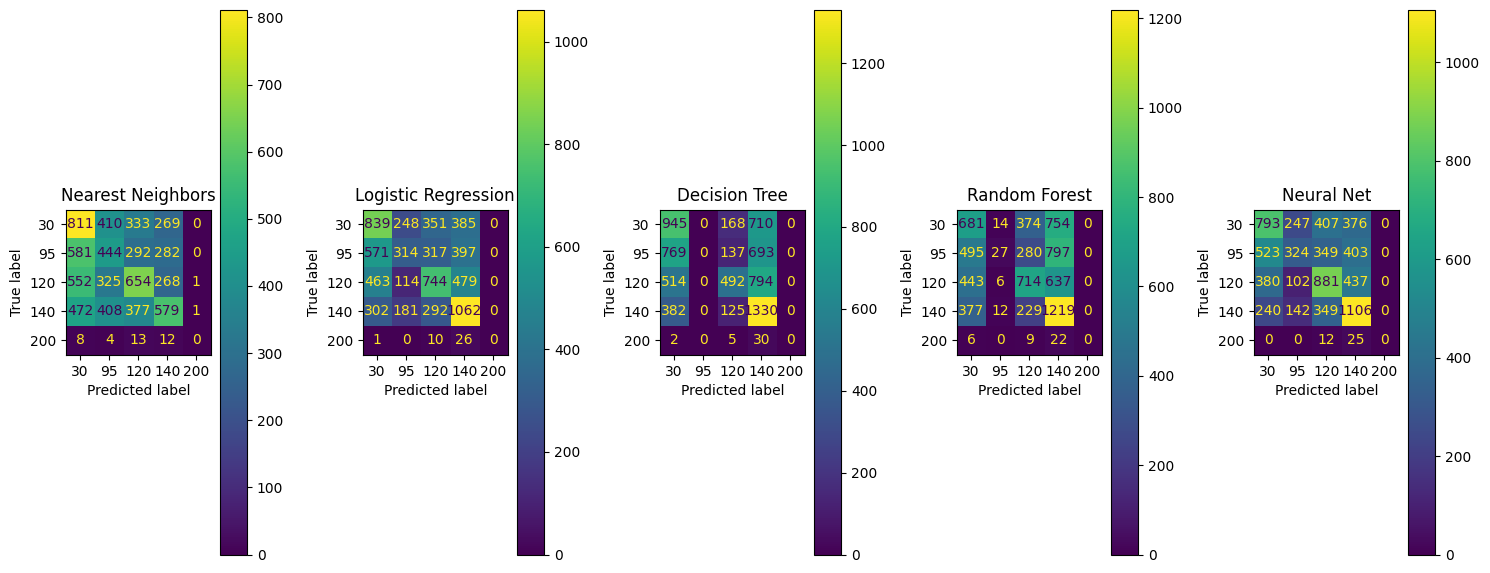

In [23]:
# without feature selection

fig, axes = plt.subplots(nrows=1, ncols=len(model_map), figsize=(15,10))

# print(axes)
# confusion_mat_wo_ft_selection = {}
col = 0
for model_name, model in model_map.items():
    model.fit(X_train, y_train)
    print(f"Without Feature Selection: Trained model: {model_name}")
    print(f"Without Feature Selection: {model_name} : {round(model.score(X_test, y_test) * 100, 2)}")

    predicted_y = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, predicted_y))

    cm = confusion_matrix(y_test, predicted_y)
    print("Confusion Matrix:\n")
    print(cm)
    print(classification_report(y_test, predicted_y))
    print("--------------------------------------------------------")

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=tempo_bins).plot(ax=axes[col])
    axes[col].set_title(f"{model_name}")
    col += 1

plt.tight_layout()
plt.show()

Scaled data: Trained model: Nearest Neighbors
Scaled data: Nearest Neighbors : 35.06
--------------------------------------------------------
Accuracy: 0.3506200676437429
Confusion Matrix:

[[811 410 333 269   0]
 [581 444 292 282   0]
 [552 325 654 268   1]
 [472 408 377 579   1]
 [  8   4  13  12   0]]
              precision    recall  f1-score   support

           0       0.33      0.44      0.38      1823
           1       0.28      0.28      0.28      1599
           2       0.39      0.36      0.38      1800
           3       0.41      0.32      0.36      1837
           4       0.00      0.00      0.00        37

    accuracy                           0.35      7096
   macro avg       0.28      0.28      0.28      7096
weighted avg       0.35      0.35      0.35      7096

--------------------------------------------------------
Scaled data: Trained model: Logistic Regression
Scaled data: Logistic Regression : 41.7
--------------------------------------------------------
Acc

/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

Scaled data: Trained model: Random Forest
Scaled data: Random Forest : 37.22
--------------------------------------------------------
Accuracy: 0.3721815107102593
Confusion Matrix:

[[ 681   14  374  754    0]
 [ 495   27  280  797    0]
 [ 443    6  714  637    0]
 [ 377   12  229 1219    0]
 [   6    0    9   22    0]]
              precision    recall  f1-score   support

           0       0.34      0.37      0.36      1823
           1       0.46      0.02      0.03      1599
           2       0.44      0.40      0.42      1800
           3       0.36      0.66      0.46      1837
           4       0.00      0.00      0.00        37

    accuracy                           0.37      7096
   macro avg       0.32      0.29      0.25      7096
weighted avg       0.40      0.37      0.33      7096

--------------------------------------------------------


/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

Scaled data: Trained model: Neural Net
Scaled data: Neural Net : 43.74
--------------------------------------------------------
Accuracy: 0.4374295377677565
Confusion Matrix:

[[ 793  247  407  376    0]
 [ 523  324  349  403    0]
 [ 380  102  881  437    0]
 [ 240  142  349 1106    0]
 [   0    0   12   25    0]]
              precision    recall  f1-score   support

           0       0.41      0.43      0.42      1823
           1       0.40      0.20      0.27      1599
           2       0.44      0.49      0.46      1800
           3       0.47      0.60      0.53      1837
           4       0.00      0.00      0.00        37

    accuracy                           0.44      7096
   macro avg       0.34      0.35      0.34      7096
weighted avg       0.43      0.44      0.42      7096

--------------------------------------------------------


/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

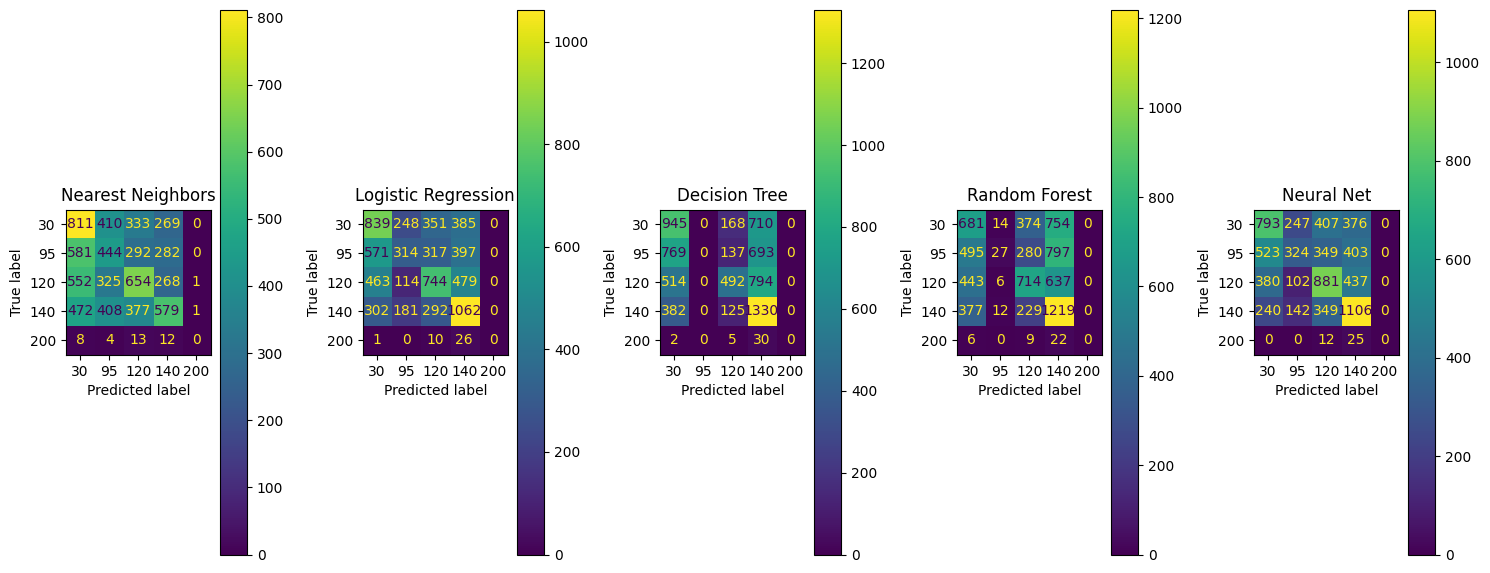

In [24]:
fig, axes = plt.subplots(nrows=1, ncols=len(model_map), figsize=(15,10))

col = 0
for model_name, model in model_map.items():
    model.fit(X_train_scaled, y_train)
    print(f"Scaled data: Trained model: {model_name}")
    print(f"Scaled data: {model_name} : {round(model.score(X_test_scaled, y_test) * 100, 2)}")
    print("--------------------------------------------------------")

    predicted_y = model.predict(X_test_scaled)
    print("Accuracy:", accuracy_score(y_test, predicted_y))

    cm = confusion_matrix(y_test, predicted_y)
    print("Confusion Matrix:\n")
    print(cm)
    print(classification_report(y_test, predicted_y))
    print("--------------------------------------------------------")

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=tempo_bins).plot(ax=axes[col])
    axes[col].set_title(f"{model_name}")
    col += 1

plt.tight_layout()
plt.show()

In [25]:
# stratified k-folds with shuffle
kfolds = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=_RANDOM_STATE
)

In [26]:
# Folds, NN, Selected Feature
mlp = MLPClassifier(alpha=1, max_iter=400, random_state=_RANDOM_STATE)
scores_explicit_skf = cross_val_score(mlp, X_train_selected, y_train, cv=kfolds, scoring='accuracy')
print(f"\nAccuracy scores using explicit StratifiedKFold (5-fold): {scores_explicit_skf}")
print(f"Mean Accuracy: {scores_explicit_skf.mean():.4f} (+/- {scores_explicit_skf.std() * 2:.4f})")



Accuracy scores using explicit StratifiedKFold (5-fold): [0.4224062  0.43420821 0.42821913 0.43685045 0.42847075]
Mean Accuracy: 0.4300 (+/- 0.0101)


In [27]:
# Parameter tuning via RandomizedSearchCV
# Ref: https://medium.com/@aditib259/a-comprehensive-guide-to-hyperparameter-tuning-in-machine-learning-dd9bb8072d02

# Define hyperparameters with a range of values
param_dist = {
    'n_estimators': randint(10, 200),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 11)
}

# Initialize model
rf = RandomForestClassifier()

# Perform Randomized Search
random_search = RandomizedSearchCV(rf, param_dist, n_iter=10, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)
random_search.fit(X_train_selected, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_split': 9, 'n_estimators': 198}
Best Score: 0.4482808243095572


Score: 45.49
--------------------------------------------------------
Accuracy: 0.4549041713641488
Confusion Matrix:

[[ 817  300  343  363    0]
 [ 471  436  297  395    0]
 [ 372  153  841  434    0]
 [ 256  169  278 1134    0]
 [   3    1    7   26    0]]
              precision    recall  f1-score   support

           0       0.43      0.45      0.44      1823
           1       0.41      0.27      0.33      1599
           2       0.48      0.47      0.47      1800
           3       0.48      0.62      0.54      1837
           4       0.00      0.00      0.00        37

    accuracy                           0.45      7096
   macro avg       0.36      0.36      0.36      7096
weighted avg       0.45      0.45      0.45      7096

--------------------------------------------------------


/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

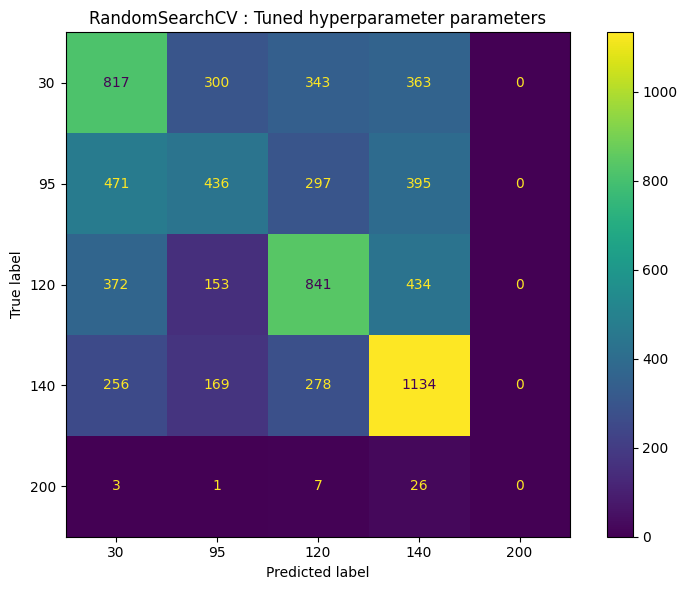

In [28]:
# plot
predicted_y = random_search.predict(X_test_selected)

# print(f"Feature Selection: Trained model: SVC : Selected Features: 5-folds: Tuned parameters")
print(f"Score: {round(random_search.score(X_test_selected, y_test) * 100, 2)}")
print("--------------------------------------------------------")

print("Accuracy:", accuracy_score(y_test, predicted_y))

cm = confusion_matrix(y_test, predicted_y)
print("Confusion Matrix:\n")
print(cm)
print(classification_report(y_test, predicted_y))
print("--------------------------------------------------------")

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 6))

# print(axes)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=tempo_bins).plot(ax=axes)
axes.set_title("RandomSearchCV : Tuned hyperparameter parameters")

plt.tight_layout()
plt.show()

In [29]:
# extract the tuned parameters
# Print the best parameters found
print("Best Model: ", random_search.best_estimator_)
print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Best Model:  RandomForestClassifier(max_depth=20, min_samples_split=9, n_estimators=198)
Best Parameters: {'max_depth': 20, 'min_samples_split': 9, 'n_estimators': 198}
Best Score: 0.4482808243095572


In [30]:
# go through NN and RandomForest
from scipy.stats import randint, uniform

para_tuning_pipe = Pipeline([('clf', RandomForestClassifier())])

# parameters for tuning for different model
param_distributions = [
    {
        'clf': [RandomForestClassifier()],
        'clf__n_estimators': randint(10, 200),
        'clf__max_depth': [None, 10, 20, 30],
        'clf__min_samples_split': randint(2, 11)
    },
    {
        'clf': [MLPClassifier(alpha=1, max_iter=400, random_state=_RANDOM_STATE)],
        'clf__hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
        'clf__activation': ['tanh', 'relu'],
        'clf__solver': ['sgd', 'adam'],
        'clf__alpha': uniform(0.0001, 0.05), # Continuous distribution
        'clf__learning_rate_init': uniform(0.001, 0.01),
        'clf__max_iter': [200, 300]
    }
]

random_search = RandomizedSearchCV(para_tuning_pipe, param_distributions, n_iter=10, cv=5, scoring='accuracy', n_jobs=-1)
random_search.fit(X_train_selected, y_train)

/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum i

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'clf': [RandomForestClassifier()], 'clf__max_depth': [None, 10, ...], 'clf__min_samples_split': <scipy.stats....t 0x114f26060>, 'clf__n_estimators': <scipy.stats....t 0x117961bd0>}, {'clf': [MLPClassifier...ndom_state=42)], 'clf__activation': ['tanh', 'relu'], 'clf__alpha': <scipy.stats....t 0x114f292b0>, 'clf__hidden_layer_sizes': [(50,), (100,), ...], ...}]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is use

In [31]:
# Print the best parameters found
print("Best Model: ", random_search.best_estimator_)
print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Best Model:  Pipeline(steps=[('clf',
                 RandomForestClassifier(min_samples_split=9,
                                        n_estimators=190))])
Best Parameters: {'clf': RandomForestClassifier(), 'clf__max_depth': None, 'clf__min_samples_split': 9, 'clf__n_estimators': 190}
Best Score: 0.44680132473267564


In [32]:
# fit the best model again, with best parameters
best_model = random_search.best_estimator_
best_predicted_y = best_model.predict(X_test_selected)

print(f"Score: {round(random_search.score(X_test_selected, y_test) * 100, 2)}")
print("--------------------------------------------------------")
print("Accuracy:", accuracy_score(y_test, best_predicted_y))

cm = confusion_matrix(y_test, best_predicted_y)
print("Confusion Matrix:\n")
print(cm)
print(classification_report(y_test, best_predicted_y))
print("--------------------------------------------------------")

Score: 45.05
--------------------------------------------------------
Accuracy: 0.45053551296505073
Confusion Matrix:

[[ 794  312  356  361    0]
 [ 469  437  300  393    0]
 [ 368  170  843  419    0]
 [ 254  188  272 1123    0]
 [   3    1    8   25    0]]
              precision    recall  f1-score   support

           0       0.42      0.44      0.43      1823
           1       0.39      0.27      0.32      1599
           2       0.47      0.47      0.47      1800
           3       0.48      0.61      0.54      1837
           4       0.00      0.00      0.00        37

    accuracy                           0.45      7096
   macro avg       0.35      0.36      0.35      7096
weighted avg       0.44      0.45      0.44      7096

--------------------------------------------------------


/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

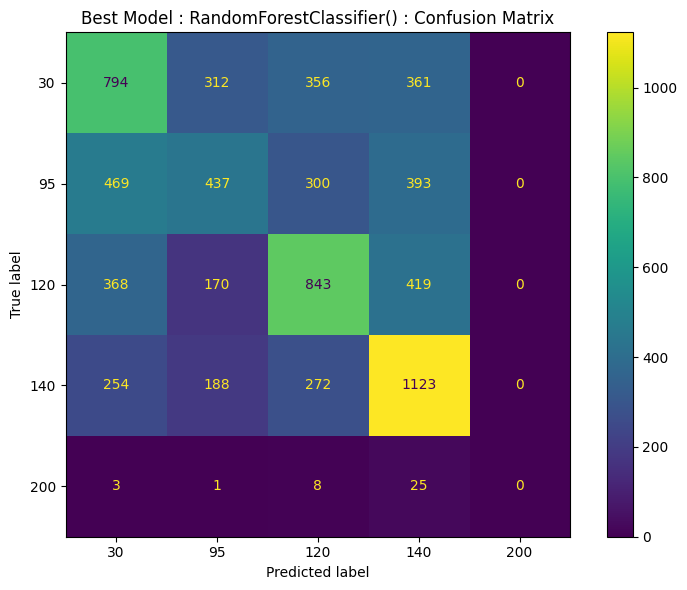

In [33]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8,6))

# print(tempo_labels)
# print(random_search.classes_)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=tempo_bins).plot(ax=axes)
axes.set_title(f"Best Model : {random_search.best_params_['clf']} : Confusion Matrix")

plt.tight_layout()
plt.show()

In [34]:
#### trncate the forest trees

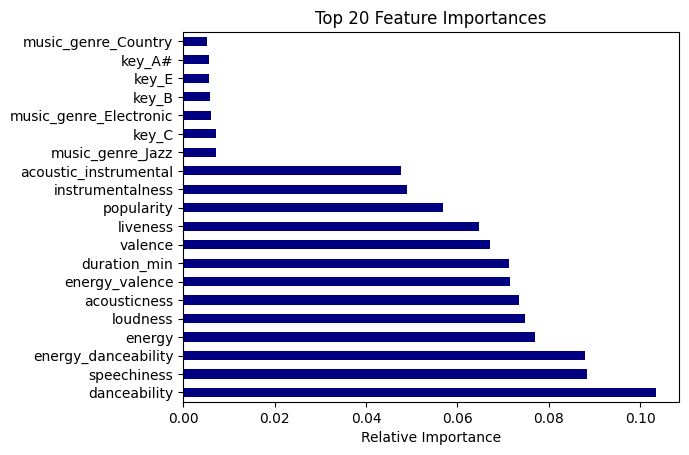

In [35]:
# Get importances and sort them
# print(best_model['clf'].feature_importances_)
importances = pd.Series(best_model['clf'].feature_importances_, index=X_test_selected.columns)
importances.nlargest(20).plot(kind='barh', color='navy')

plt.title('Top 20 Feature Importances')
plt.xlabel('Relative Importance')
plt.show()

In [36]:
# Sample recommendation
import random
print(X_test_selected.shape)
random_idx = random.randint(0, X_test_selected.shape[0])
print(random_idx)
sample_X_reco = X_test_selected.iloc[random_idx-4:random_idx]
sample_X_reco

(7096, 26)
6053


,popularity,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,key_A#,...,music_genre_Country,music_genre_Electronic,music_genre_Hip-Hop,music_genre_Jazz,music_genre_Rap,music_genre_Rock,duration_min,energy_danceability,energy_valence,acoustic_instrumental
15900,0.039123,-0.529222,0.051847,-0.338000,-0.592486,-0.891783,0.392619,-0.638567,0.872662,-0.265649,...,2.895901,-0.349899,-0.297297,-0.348057,-0.289792,-0.317751,-0.214826,-0.329699,0.181233,-0.429996
27413,0.750213,-0.486394,-0.277244,0.492097,-0.592503,-0.477396,0.337910,-0.548759,-0.330950,-0.265649,...,-0.345316,-0.349899,-0.297297,-0.348057,-0.289792,3.147116,-0.627379,0.128284,-0.124699,-0.429999
31144,-2.158791,1.706422,-0.472468,-1.520704,1.101478,-0.532894,-1.347517,-0.401516,0.403254,3.764372,...,-0.345316,-0.349899,-0.297297,-0.348057,-0.289792,-0.317751,-0.374624,-1.408605,-0.913459,1.603527
16997,-0.413389,-0.705390,-0.846182,0.223969,-0.592431,-0.576060,0.679223,-0.486102,-0.936768,-0.265649,...,2.895901,-0.349899,-0.297297,-0.348057,-0.289792,-0.317751,-0.202601,-0.437406,-0.705552,-0.429993


In [37]:
sample_y_reco = best_model.predict(sample_X_reco)
print(sample_y_reco)

[2 3 1 3]


In [43]:
for predicted_tempo in sample_y_reco:
    # print(predicted_tempo)
    tempo_tmp = original_df.loc[transformed_df["tempo_group"] == tempo_labels[predicted_tempo]]
    random_art_idx = random.randint(0, len(tempo_tmp))
    # print(random_art_idx)
    print(f"Recommended tracks: {tempo_tmp.iloc[random_idx-1:random_idx][['artist_name', 'track_name', 'tempo']]}")


Recommended tracks:       artist_name            track_name    tempo
26182    Bad Suns  Dancing On Quicksand  124.027
Recommended tracks:       artist_name                             track_name    tempo
21617     Santana  Dance Sister Dance (Baila Mi Hermana)  152.772
Recommended tracks:        artist_name              track_name   tempo
23222  Ana Popovic  Lives That Don't Exist  100.61
Recommended tracks:       artist_name                             track_name    tempo
21617     Santana  Dance Sister Dance (Baila Mi Hermana)  152.772
